In [267]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [268]:
df=pd.read_csv('netflix.csv')

In [269]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Columns Type
- Numeric Type: release_year
- Categorical Type: show_id, type, title, director, country
- mixed type: cast, date_added, rating, duration , listed_in, description

In [270]:
df.shape

(8807, 12)

In [271]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


- In  this datasets, we have 8807 entities. And some of the columes contain less than 8807 entities so there are some missing values (director,cast,country,date_added, rating,duration)
- released year column should be datetime Dtype but there is int Dtype so we need to transfor into datetime

In [272]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### data cleaning

In [273]:
# handling director, cast and country columns by filling value in missing position
df['director']=df['director'].fillna('unknown')
df['cast']=df['cast'].fillna('unknown')
df['country']=df['country'].fillna('country')
df['cast'].isnull().sum()

np.int64(0)

In [274]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

In [275]:
# handling date_time, rating, duration by dropping missing values
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [276]:
# transforming date_added column into datetime object
df['date_added']=pd.to_datetime(df['date_added'], format='mixed')

In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 892.7+ KB


In [278]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",country,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,country,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [279]:
df['release_year'].describe()

count    8790.000000
mean     2014.183163
std         8.825466
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

<Axes: ylabel='Density'>

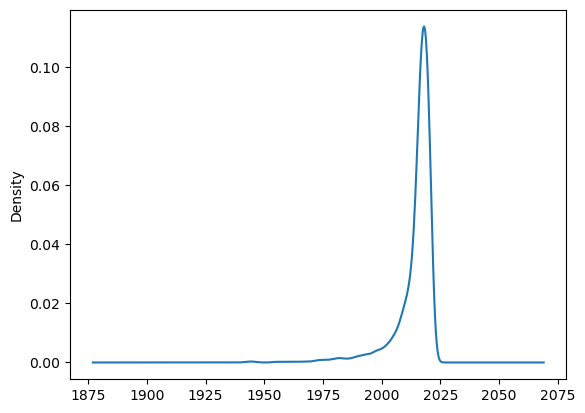

In [280]:
df['release_year'].plot(kind='kde')

<Axes: >

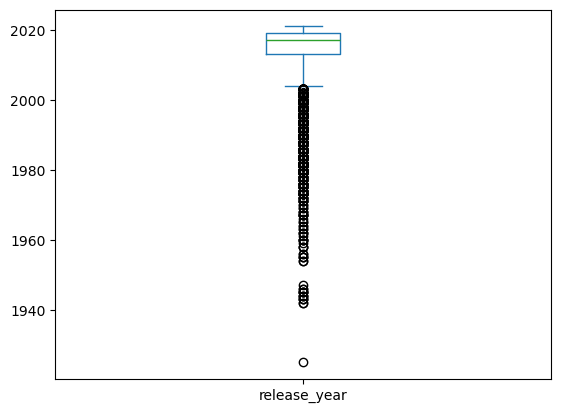

In [281]:
df['release_year'].plot(kind='box')

In [282]:
df[df['release_year']<2000]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",country,2021-09-21,1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
26,s27,Movie,Minsara Kanavu,Rajiv Menon,"Arvind Swamy, Kajol, Prabhu Deva, Nassar, S.P....",country,2021-09-21,1997,TV-PG,147 min,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...
41,s42,Movie,Jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,2021-09-16,1975,PG,124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...
...,...,...,...,...,...,...,...,...,...,...,...,...
8745,s8746,Movie,Willy Wonka & the Chocolate Factory,Mel Stuart,"Gene Wilder, Jack Albertson, Peter Ostrum, Roy...","United States, East Germany, West Germany",2020-01-01,1971,G,100 min,"Children & Family Movies, Classic Movies, Come...",Zany Willy Wonka causes a stir when he announc...
8748,s8749,Movie,Winter of Our Dreams,John Duigan,"Judy Davis, Bryan Brown, Cathy Downes, Baz Luh...",Australia,2016-11-01,1981,NR,86 min,"Classic Movies, Dramas","After the death of a long-ago lover, married p..."
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,unknown,United States,2017-03-31,1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...
8764,s8765,Movie,Wyatt Earp,Lawrence Kasdan,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,2020-01-01,1994,PG-13,191 min,Action & Adventure,Legendary lawman Wyatt Earp is continually at ...


In [283]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

<Axes: xlabel='type'>

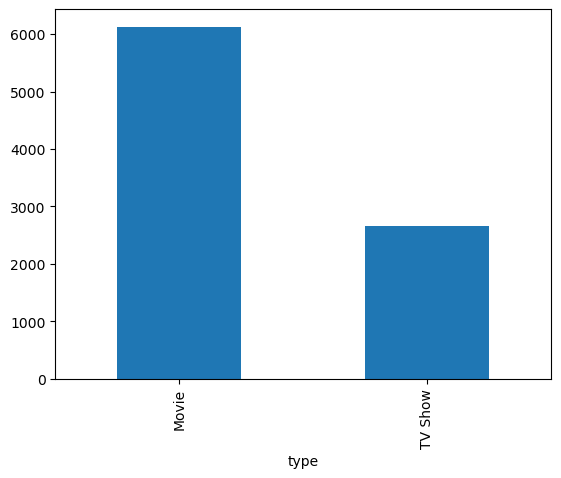

In [284]:
df['type'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

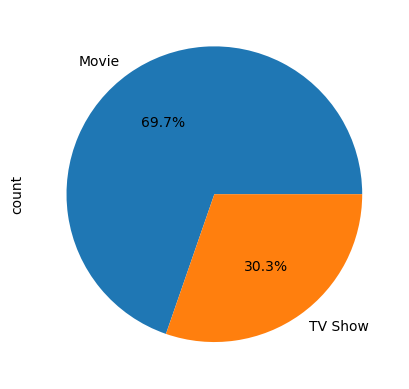

In [285]:
df['type'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [286]:
df['director'].value_counts().head(10)

director
unknown                   2621
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Martin Scorsese             12
Jay Chapman                 12
Youssef Chahine             12
Name: count, dtype: int64

In [287]:
temp_df=df[df['director'] != 'unknown']['director'].value_counts().head(10)
temp_df

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Jay Chapman               12
Youssef Chahine           12
Steven Spielberg          11
Name: count, dtype: int64

<Axes: xlabel='director'>

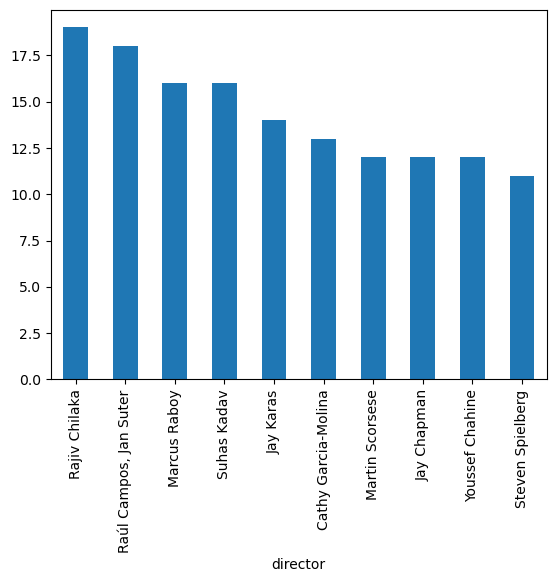

In [288]:
temp_df.plot(kind='bar')

In [289]:
# feature engineering on year_added column
df['year_added']=df['date_added'].dt.year
df['year_month']=df['date_added'].dt.month

In [290]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,year_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",country,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,country,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


In [291]:
# number of Movies and TV Shows changed over time
# df.groupby(['year_added', 'type']).size().unstack() 
temp_df= pd.crosstab(df['year_added'], df['type'])
temp_df

type,Movie,TV Show
year_added,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,5
2014,19,5
2015,56,26
2016,251,175


<Axes: xlabel='year_added'>

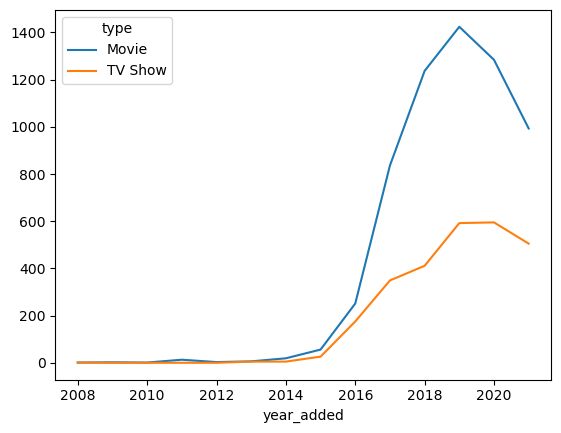

In [292]:
temp_df.plot(kind='line')

In [293]:
df['listed_in'] = df['listed_in'].str.split(', ')
df = df.explode('listed_in')

In [294]:
df = df.rename(columns={'listed_in': 'genre'})

<Axes: xlabel='genre'>

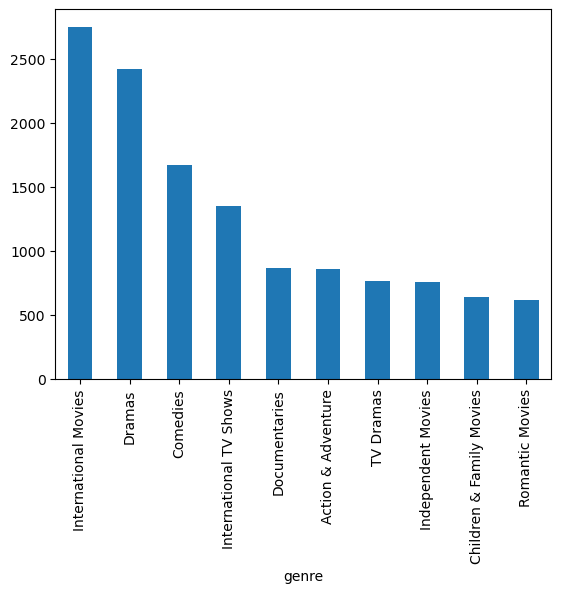

In [295]:
df['genre'].value_counts().head(10).plot(kind='bar')

In [296]:
df['release_year'].value_counts().head(1)

release_year
2018    2512
Name: count, dtype: int64

so, the year 2018 has the highest number of titles was released.

<Axes: ylabel='Density'>

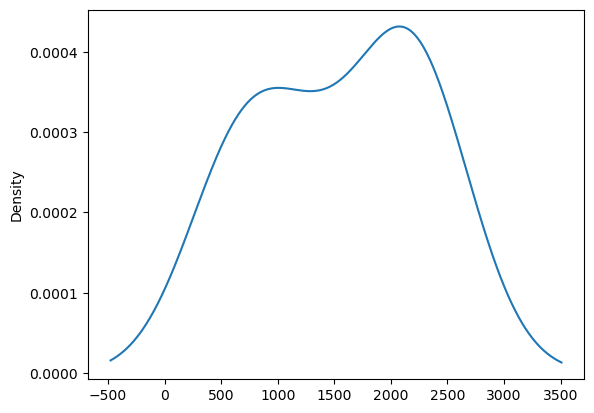

In [297]:
df['release_year'].value_counts().head(10).plot(kind='kde')

In [298]:
df[df['release_year']==df['release_year'].min()][['title', 'release_year']]

,title,release_year
4250,Pioneers: First Women Filmmakers*,1925


In [299]:
df[df['release_year']==df['release_year'].max()][['title', 'release_year']]

,title,release_year
1,Blood & Water,2021
1,Blood & Water,2021
1,Blood & Water,2021
2,Ganglands,2021
2,Ganglands,2021
...,...,...
1696,Polly Pocket,2021
2920,Love Is Blind,2021
2920,Love Is Blind,2021
8437,The Netflix Afterparty,2021


- So, oldest title is 'Pioneers: First Women Filmmakers*' which was released on 1925 available on netflix
- And there are multiple titles(newest) which are released on 2021 available on netflix

In [300]:
df['year_added'].value_counts().head(1)

year_added
2019    4507
Name: count, dtype: int64

<Axes: xlabel='year_added'>

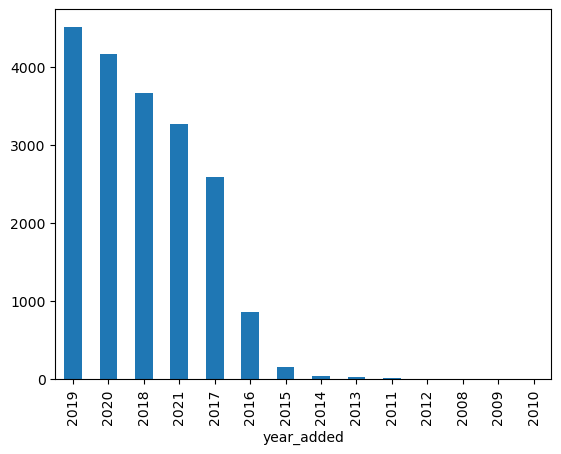

In [301]:
df['year_added'].value_counts().plot(kind='bar')

- most number of content added to netflix on 2019(4507 movies and tv shows) and followed by 2020.

In [302]:
df['released_added_gap']=df['year_added']- df['release_year']

In [303]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,year_added,year_month,released_added_gap
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,1
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,9,0
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021,9,0
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021,9,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",country,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,Children & Family Movies,"Dragged from civilian life, a former superhero...",2020,1,14
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,Comedies,"Dragged from civilian life, a former superhero...",2020,1,14
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,Dramas,A scrappy but poor boy worms his way into a ty...,2019,3,4
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,International Movies,A scrappy but poor boy worms his way into a ty...,2019,3,4


In [304]:
df['country'].value_counts()

country
United States                     4987
India                             2626
country                           1720
United Kingdom                     954
Japan                              584
                                  ... 
Spain, Thailand, United States       1
South Korea, France                  1
United States, China, Colombia       1
United Kingdom, South Korea          1
Ireland, Canada                      1
Name: count, Length: 749, dtype: int64

<Axes: xlabel='country'>

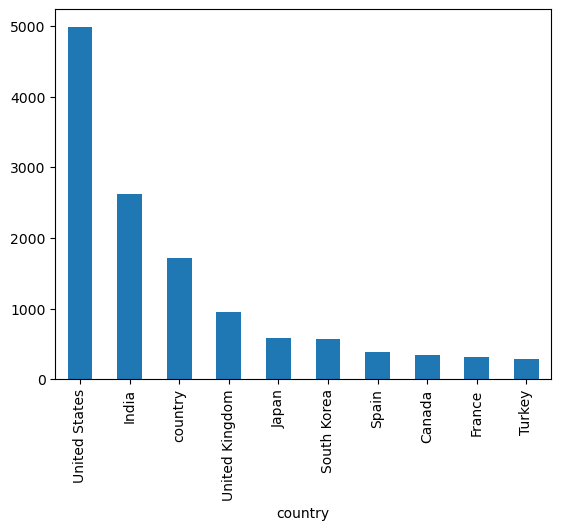

In [305]:
df['country'].value_counts().head(10).plot(kind='bar')

- USA is the most number of content contributed country on netflix and followed by second most contributed country is india

In [306]:
df[df['type']=='Movie'][['country']].value_counts()

country                                      
United States                                    3614
India                                            2437
country                                           857
United Kingdom                                    376
Spain                                             242
                                                 ... 
France, Belgium, China, United States               1
France, United States, United Kingdom, Canada       1
Switzerland, France, Belgium, United States         1
United States, France, United Kingdom, Japan        1
United States, Denmark                              1
Name: count, Length: 652, dtype: int64

In [307]:
df[df['type']=='TV Show'][['country']].value_counts()

country                                       
United States                                     1373
country                                            863
United Kingdom                                     578
South Korea                                        459
Japan                                              384
                                                  ... 
United States, France, Canada                        1
Ireland, Canada, United States, United Kingdom       1
India, Germany, France                               1
United States, France, South Korea, Indonesia        1
Denmark, Singapore, Canada, United States            1
Name: count, Length: 197, dtype: int64

- usa produces most number of both movies and tv shows

In [308]:
# seperate movies and tv show
movies_df=df[df['type']== 'Movie'].copy()
tv_shows_df=df[df['type']== 'TV Show'].copy()

Text(0.5, 1.0, 'Movie Duration Distribution(Minutes)')

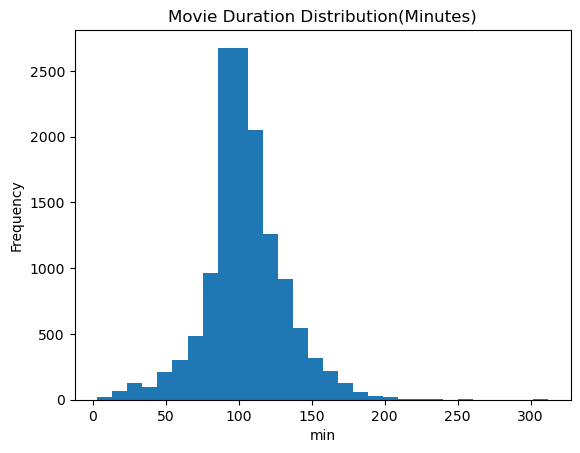

In [309]:
movies_df['duration']=movies_df['duration'].str.replace(' min', '').astype('int')
movies_df['duration'].plot(kind='hist', xlabel='min', bins=30).set_title('Movie Duration Distribution(Minutes)')

Text(0.5, 1.0, 'TV Show Seasons Distrubution')

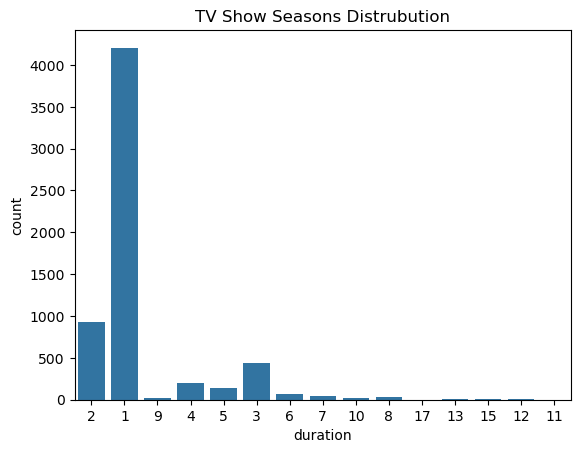

In [310]:
tv_shows_df['duration']=tv_shows_df['duration'].str.replace(' Season', '').str.replace('s', '')
sns.countplot(data=tv_shows_df, x='duration').set_title('TV Show Seasons Distrubution')

- The majority of the movies on netflix are in the range between 80 to 120 minutes
- And the vast majority of tv shows on netflix has only one season


In [312]:
cast_df = df.copy()

cast_df['cast'] = cast_df['cast'].str.split(', ')
cast_df = cast_df.explode('cast')

In [313]:
cast_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,year_added,year_month,released_added_gap
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,1
1,s2,TV Show,Blood & Water,unknown,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,9,0
1,s2,TV Show,Blood & Water,unknown,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,9,0
1,s2,TV Show,Blood & Water,unknown,Gail Mabalane,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,9,0
1,s2,TV Show,Blood & Water,unknown,Thabang Molaba,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,s8807,Movie,Zubaan,Mozez Singh,Manish Chaudhary,India,2019-03-02,2015,TV-14,111 min,Music & Musicals,A scrappy but poor boy worms his way into a ty...,2019,3,4
8806,s8807,Movie,Zubaan,Mozez Singh,Meghna Malik,India,2019-03-02,2015,TV-14,111 min,Music & Musicals,A scrappy but poor boy worms his way into a ty...,2019,3,4
8806,s8807,Movie,Zubaan,Mozez Singh,Malkeet Rauni,India,2019-03-02,2015,TV-14,111 min,Music & Musicals,A scrappy but poor boy worms his way into a ty...,2019,3,4
8806,s8807,Movie,Zubaan,Mozez Singh,Anita Shabdish,India,2019-03-02,2015,TV-14,111 min,Music & Musicals,A scrappy but poor boy worms his way into a ty...,2019,3,4


In [321]:
cast_df[cast_df['cast']!='unknown'][['cast']].value_counts()

cast            
Anupam Kher         120
Shah Rukh Khan       99
Naseeruddin Shah     92
Akshay Kumar         85
Paresh Rawal         79
                   ... 
Ski Carr              1
Siu-See Hung          1
Isaac Leyva           1
Isabel Conner         1
Hussain Alyahya       1
Name: count, Length: 36392, dtype: int64

<Axes: xlabel='cast'>

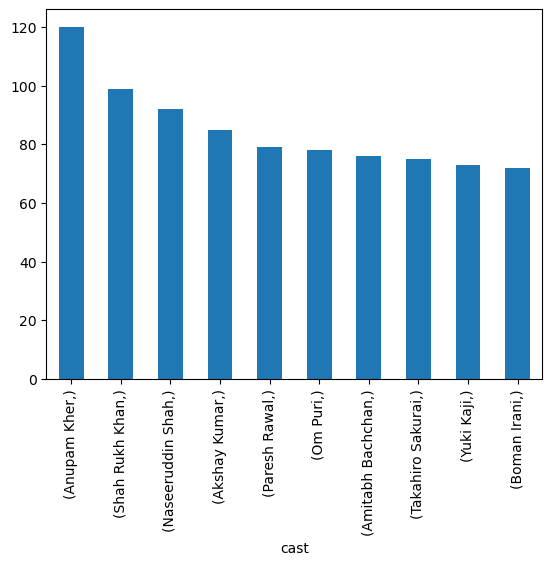

In [326]:
cast_df[cast_df['cast']!='unknown'][['cast']].value_counts().head(10).plot(kind='bar')

- Anupam Kher appear most frequently on Netflix

In [324]:
cast_df[(cast_df['country'] != 'India') &(cast_df['cast'] != 'unknown')]['cast'].value_counts()

cast
Takahiro Sakurai    75
Yuki Kaji           73
Daisuke Ono         52
Junichi Suwabe      50
Mamoru Miyano       48
                    ..
Stuart Allan         1
Jon Arthur           1
Wayne Pére           1
Al Vicente           1
Johnny Weir          1
Name: count, Length: 33203, dtype: int64